<a href="https://colab.research.google.com/github/shreyanshhub/ADSA-assignment-/blob/main/AAssihnment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ndjson

In [23]:
import os
import ndjson
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display
from collections import Counter
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [24]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
set_seed(42)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_built() and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


In [25]:
#increase number of categories as per requirement here
CATEGORIES = ["apple", "car", "donut", "ladder", "tree", "door", "baseball", "pizza", "hexagon", "circle"]
class_to_idx = {category: idx for idx, category in enumerate(CATEGORIES)}
NUM_CLASSES = len(CATEGORIES)
MAX_SEQ_LENGTH = 250

#function definitinos for data loading for all categories
def load_multiclass_drawings(data_folder, categories, num_samples_per_class=5000):
    all_drawings = []
    all_labels = []
    for category in categories:
        file_path = os.path.join(data_folder, f"{category}.ndjson")
        if not os.path.exists(file_path):
            print(f"File for category {category} not found!")
            continue
        print(f"Loading {category}...")
        count = 0
        with open(file_path, 'r') as f:
            reader = ndjson.reader(f)
            for obj in reader:
                if obj['recognized']:
                    all_drawings.append(obj['drawing'])
                    all_labels.append(class_to_idx[category])
                    count += 1
                    if count >= num_samples_per_class:
                        break
        print(f"Loaded {count} drawings for {category}")
    return all_drawings, all_labels

#function definitinos for all required preprocessings
def get_global_min_max(drawings):
    all_x, all_y = [], []
    for drawing in drawings:
        for stroke in drawing:
            all_x.extend(stroke[0])
            all_y.extend(stroke[1])
    return min(all_x), max(all_x), min(all_y), max(all_y)

def convert_to_penstate(drawing, y_max):
    strokes_with_pen = []
    for stroke in drawing:
        x_seq, y_seq = stroke[0], stroke[1]
        y_seq_inverted = [y_max - y for y in y_seq]
        for i in range(len(x_seq)):
            strokes_with_pen.append((x_seq[i], y_seq_inverted[i], 1))
        strokes_with_pen.append((x_seq[-1], y_seq_inverted[-1], 0))
    if strokes_with_pen:
        last_x, last_y, _ = strokes_with_pen[-1]
        strokes_with_pen[-1] = (last_x, last_y, 2)
    return strokes_with_pen

def filter_incomplete_drawings(drawings_batch, min_strokes=1, min_points=2):
    filtered_batch = []
    for drawing in drawings_batch:
        num_strokes = sum(1 for x, y, pen in drawing if pen == 0)
        if len(drawing) >= min_points and num_strokes >= min_strokes:
            filtered_batch.append(drawing)
    return filtered_batch

def normalize_drawing(strokes_with_pen):
    x_vals = [x for x, y, pen in strokes_with_pen if pen != 2]
    y_vals = [y for x, y, pen in strokes_with_pen if pen != 2]

    x_mean = sum(x_vals) / len(x_vals)
    y_mean = sum(y_vals) / len(y_vals)

    x_vals = [x - x_mean for x in x_vals]
    y_vals = [y - y_mean for y in y_vals]

    max_abs = max(max(abs(x) for x in x_vals), max(abs(y) for y in y_vals)) or 1
    x_vals = [x / max_abs for x in x_vals]
    y_vals = [y / max_abs for y in y_vals]

    normalized_strokes = []
    idx = 0
    for x, y, pen in strokes_with_pen:
        if pen != 2:
            normalized_x = x_vals[idx]
            normalized_y = y_vals[idx]
            normalized_strokes.append((normalized_x, normalized_y, pen))
            idx += 1
        else:
            normalized_strokes.append((0, 0, 2))

    return normalized_strokes

def convert_to_deltas(strokes_with_pen):
    delta_strokes = []
    prev_x, prev_y = None, None

    for x, y, pen in strokes_with_pen:
        if pen != 2:
            if prev_x is None:
                dx, dy = 0, 0
            else:
                dx = x - prev_x
                dy = y - prev_y
            delta_strokes.append((dx, dy, pen))
            prev_x, prev_y = x, y
        else:
            delta_strokes.append((0, 0, 2))

    return delta_strokes

def pad_or_truncate(drawing, max_seq_length=250):
    padded = drawing.copy()
    if len(padded) > max_seq_length:
        padded = padded[:max_seq_length]
    else:
        while len(padded) < max_seq_length:
            padded.append((0, 0, 2))
    return padded

def preprocess_pipeline(drawings, y_max, max_seq_length=250):
    converted = []
    valid_indices = []
    for idx, drawing in enumerate(drawings):
        pen_strokes = convert_to_penstate(drawing, y_max)
        converted.append((idx, pen_strokes))

    filtered = []
    for idx, d in converted:
        #if len(filter_incomplete_drawings([d])) > 0: #testing6 removing the filter
        normalized = normalize_drawing(d)
        deltas = convert_to_deltas(normalized)
        padded = pad_or_truncate(deltas, max_seq_length)
        filtered.append((idx, padded))

    processed_batch = [padded for idx, padded in filtered]
    valid_indices = [idx for idx, padded in filtered]
    return processed_batch, valid_indices

def one_hot_pen_states(batch):
    one_hot_encoded = []
    for drawing in batch:
        new_drawing = []
        for dx, dy, pen in drawing:
            pen_one_hot = [0, 0, 0]
            pen_one_hot[int(pen)] = 1
            new_drawing.append([dx, dy] + pen_one_hot)
        one_hot_encoded.append(new_drawing)
    return np.array(one_hot_encoded, dtype=np.float32)


In [26]:
class StrokeDataset(Dataset):
    def __init__(self, X_data, Y_data, class_labels):
        self.X = X_data
        self.Y = Y_data
        self.class_labels = class_labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.class_labels[idx]


In [27]:
#calling the above defined functions in a pipeline for loading and preprocessing of data
data_folder = "./"  #set path as per location of data files

drawings, labels = load_multiclass_drawings(data_folder=data_folder,
                                            categories=CATEGORIES,
                                            num_samples_per_class=10000) #testing2 number of samples

print(f"\nTotal drawings loaded: {len(drawings)}")

x_min, x_max, y_min, y_max = get_global_min_max(drawings)

preprocessed_drawings, valid_indices = preprocess_pipeline(drawings, y_max, max_seq_length=250)
print(f"\nTotal preprocessed: {len(preprocessed_drawings)}")

filtered_labels = [labels[i] for i in valid_indices]
print(f"\nLabels length after filtering: {len(filtered_labels)}")

one_hot_drawings = one_hot_pen_states(preprocessed_drawings)
print(f"\nOne-hot shape: {one_hot_drawings.shape}")


Loading apple...
Loaded 10000 drawings for apple
Loading car...
Loaded 10000 drawings for car
Loading donut...
Loaded 10000 drawings for donut
Loading ladder...
Loaded 10000 drawings for ladder
Loading tree...
Loaded 10000 drawings for tree
Loading door...
Loaded 10000 drawings for door
Loading baseball...
Loaded 10000 drawings for baseball
Loading pizza...
Loaded 10000 drawings for pizza
Loading hexagon...
Loaded 10000 drawings for hexagon
Loading circle...
Loaded 10000 drawings for circle

Total drawings loaded: 100000

Total preprocessed: 100000

Labels length after filtering: 100000

One-hot shape: (100000, 250, 5)


In [28]:
label_counts = Counter(filtered_labels)

print("\nLabel counts after preprocessing:")
for idx, count in sorted(label_counts.items()):
    label_name = CATEGORIES[idx]
    print(f"{label_name:10s}: {count}")



Label counts after preprocessing:
apple     : 10000
car       : 10000
donut     : 10000
ladder    : 10000
tree      : 10000
door      : 10000
baseball  : 10000
pizza     : 10000
hexagon   : 10000
circle    : 10000


In [29]:
X = one_hot_drawings[:, :-1, :]  #input sequence
Y = one_hot_drawings[:, 1:, :]   #target sequence

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)
labels_tensor = torch.tensor(filtered_labels, dtype=torch.long)

print(f"Input Tensor shape X: {X_tensor.shape}")
print(f"Input Tensor shape Y: {Y_tensor.shape}")
print(f"Label Tensor shape: {labels_tensor.shape}")


Input Tensor shape X: torch.Size([100000, 249, 5])
Input Tensor shape Y: torch.Size([100000, 249, 5])
Label Tensor shape: torch.Size([100000])


In [30]:
#splitting data into 70-15-15
X_train, X_temp, Y_train, Y_temp, labels_train, labels_temp = train_test_split(
    X_tensor, Y_tensor, labels_tensor, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test, labels_val, labels_test = train_test_split(
    X_temp, Y_temp, labels_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")


Train: 70000, Val: 15000, Test: 15000


In [31]:
BATCH_SIZE = 32 #testing3 increasing batch size (reverted)

train_dataset = StrokeDataset(X_train, Y_train, labels_train)
val_dataset = StrokeDataset(X_val, Y_val, labels_val)
test_dataset = StrokeDataset(X_test, Y_test, labels_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [32]:
def deltas_to_absolute(deltas):
    abs_x, abs_y = 0, 0
    abs_points = []
    for dx, dy, pen in deltas:
        abs_x += dx
        abs_y += dy
        abs_points.append((abs_x, abs_y, pen))
    return abs_points

#visualization function to simulate hand drawn sketches
def visualize_pointwise_colored_general(strokes, delay=0.01, is_delta=False, fixed_scale=True):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.axis('off')
    abs_strokes = []
    if is_delta:
        abs_x, abs_y = 0, 0
        for dx, dy, pen in strokes:
            abs_x += dx
            abs_y += dy
            abs_strokes.append((abs_x, abs_y, pen))
    else:
        abs_strokes = strokes
    if fixed_scale:
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
    all_strokes = []
    current_stroke_x, current_stroke_y = [], []
    def get_random_color():
        return (random.random(), random.random(), random.random())
    current_color = get_random_color()
    for x, y, pen in abs_strokes:
        if pen == 1:
            current_stroke_x.append(x)
            current_stroke_y.append(y)
        else:
            if len(current_stroke_x) > 0:
                all_strokes.append((current_stroke_x.copy(), current_stroke_y.copy(), current_color))
                current_stroke_x, current_stroke_y = [], []
                current_color = get_random_color()
        clear_output(wait=True)
        ax.cla()
        ax.axis('off')
        if fixed_scale:
            ax.set_xlim(-1.2, 1.2)
            ax.set_ylim(-1.2, 1.2)
        for xs, ys, color in all_strokes:
            ax.plot(xs, ys, marker='.', color=color)
        if len(current_stroke_x) > 0:
            ax.plot(current_stroke_x, current_stroke_y, marker='.', color=current_color)
        display(fig)
        time.sleep(delay)
        if pen == 2:
            break
    plt.close(fig)


In [33]:
#model architecture with single head cross attnetion between encoder and decoder
#class embedding and input given to encoder
#class embedding, input and prev hidden state given to decoder
class GPT2Encoder(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size, num_classes):
        super(GPT2Encoder, self).__init__()
        self.embedding = nn.Embedding(num_classes, embedding_dim)
        self.lstm = nn.LSTM(input_size + embedding_dim, hidden_size, batch_first=True, num_layers=2, dropout=0.5) #testing1 dropout testing5 0.3 to 0.5
        self.layer_norm = nn.LayerNorm(hidden_size) #testing1 layernorm

    def forward(self, stroke_seq, class_label):
        """
        stroke_seq: Tensor of shape (batch_size, seq_len, input_size)
        class_label: Tensor of shape (batch_size,)
        """
        batch_size, seq_len, _ = stroke_seq.size()
        class_emb = self.embedding(class_label)
        class_emb = class_emb.unsqueeze(1).repeat(1, seq_len, 1)
        lstm_input = torch.cat([stroke_seq, class_emb], dim=2)  #batch_size, seq_len, input_size + embedding_dim
        outputs, (hidden, cell) = self.lstm(lstm_input)
        outputs = self.layer_norm(outputs) #testing1 layernorm
        return outputs, hidden, cell

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Parameter(torch.rand(hidden_size))

    def forward(self, hidden, encoder_outputs):
        """
        hidden: Tensor of shape (batch_size, hidden_size)
        encoder_outputs: Tensor of shape (batch_size, seq_len, hidden_size)
        """
        seq_len = encoder_outputs.size(1)
        hidden = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        energy = energy.permute(0, 2, 1)
        v = self.v.repeat(encoder_outputs.size(0), 1).unsqueeze(1)
        attention_weights = torch.bmm(v, energy).squeeze(1)
        return torch.softmax(attention_weights, dim=1)

class Decoder(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_classes, embedding_dim):
        super(Decoder, self).__init__()
        self.class_embedding = nn.Embedding(num_classes, embedding_dim)
        self.lstm = nn.LSTM(input_size + hidden_size + embedding_dim, hidden_size, batch_first=True, num_layers=2, dropout=0.5) #testing1 dropout testing5 0.3 to 0.5
        self.fc_out = nn.Linear(hidden_size * 2, output_size)
        self.attention = Attention(hidden_size)

        self.class_to_hidden = nn.Linear(embedding_dim, hidden_size * 2)  # 2 layers
        self.class_to_cell = nn.Linear(embedding_dim, hidden_size * 2)

        self.layer_norm = nn.LayerNorm(hidden_size) #testing1 layernorm

    def forward(self, input_step, hidden, cell, encoder_outputs, class_label, init=False):
        batch_size = input_step.size(0)
        class_emb = self.class_embedding(class_label)
        class_emb_exp = class_emb.unsqueeze(1)

        #injecting class embedding into hidden & cell for first timestep only
        if init:
            hidden_init = self.class_to_hidden(class_emb)
            cell_init = self.class_to_cell(class_emb)

            hidden = hidden_init.view(2, batch_size, -1)
            cell = cell_init.view(2, batch_size, -1)

        #for attention
        attention_weights = self.attention(hidden[-1], encoder_outputs)
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)

        lstm_input = torch.cat([input_step, context, class_emb_exp], dim=2)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        output = self.layer_norm(output) #testing1 layernorm
        output = output.squeeze(1)
        context = context.squeeze(1)
        output = self.fc_out(torch.cat([output, context], dim=1))
        return output, hidden, cell, attention_weights.squeeze(1)


In [34]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

#model hyperparameters
INPUT_SIZE = 5
EMBEDDING_DIM = 128
HIDDEN_SIZE = 256
OUTPUT_SIZE = 5

#initializing the model with AdamW and LRonPlateau
encoder = GPT2Encoder(INPUT_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, NUM_CLASSES).to(DEVICE)
decoder = Decoder(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE, NUM_CLASSES, EMBEDDING_DIM).to(DEVICE)

encoder_optimizer = optim.AdamW(encoder.parameters(), lr=0.0010)
decoder_optimizer = optim.AdamW(decoder.parameters(), lr=0.0010)

encoder_scheduler = ReduceLROnPlateau(encoder_optimizer, mode='min', factor=0.5, patience=3)
decoder_scheduler = ReduceLROnPlateau(decoder_optimizer, mode='min', factor=0.5, patience=3)

mse_loss_fn = nn.MSELoss()
cross_entropy_loss_fn = nn.CrossEntropyLoss()

In [ ]:
#initializing training parameters
num_epochs = 30 #testing2 number of epochs
#teacher_forcing_ratio = 0.7
best_val_loss = float('inf')
patience = 10
epochs_no_improve = 0

#function to decay teacher forcing to improve generalization
def get_teacher_forcing_ratio(epoch, total_epochs, start=1.0, end=0.0): #testing2 decay teacher forcing ratio
    ratio = end + (start - end) * (0.99 ** epoch)
    return max(ratio, end)

'''
#for resuming training if interupted
start_epoch = 0
if os.path.exists('checkpoint.pth'):
    checkpoint = torch.load('checkpoint.pth', map_location=DEVICE)
    encoder.load_state_dict(checkpoint['encoder'])
    decoder.load_state_dict(checkpoint['decoder'])
    encoder_optimizer.load_state_dict(checkpoint['encoder_optimizer'])
    decoder_optimizer.load_state_dict(checkpoint['decoder_optimizer'])
    encoder_scheduler.load_state_dict(checkpoint['encoder_scheduler'])
    decoder_scheduler.load_state_dict(checkpoint['decoder_scheduler'])
    best_val_loss = checkpoint['best_val_loss']
    start_epoch = checkpoint['epoch'] + 1  # resume from next
    print(f"Resuming training from epoch {start_epoch}")
for epoch in range(start_epoch, num_epochs):
'''

#training and validation loop
for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    total_train_loss = 0
    teacher_forcing_ratio = get_teacher_forcing_ratio(epoch, num_epochs, start=1.0, end=0.0)

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    pbar = tqdm(total=len(train_loader), desc=f"Training Epoch {epoch+1}")

    #training loop
    for batch_X, batch_Y, batch_class in train_loader:
        batch_X, batch_Y, batch_class = batch_X.to(DEVICE), batch_Y.to(DEVICE), batch_class.to(DEVICE)
        batch_size, seq_len, _ = batch_X.size()

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, hidden, cell = encoder(batch_X, batch_class)
        input_seq = batch_X[:, 0, :].unsqueeze(1)
        loss = 0
        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

        for t in range(1, seq_len):
            if t == 1:
                output, hidden, cell, _ = decoder(input_seq, hidden, cell, encoder_outputs, batch_class, init=True)
            else:
                output, hidden, cell, _ = decoder(input_seq, hidden, cell, encoder_outputs, batch_class)


            loss += mse_loss_fn(output[:, :2], batch_Y[:, t, :2])
            loss += cross_entropy_loss_fn(output[:, 2:], batch_Y[:, t, 2:].argmax(dim=1))

            if use_teacher_forcing:
                input_seq = batch_Y[:, t, :].unsqueeze(1)
            else:
                input_seq = output.unsqueeze(1)

        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()

        total_train_loss += loss.item() / seq_len
        pbar.set_postfix({'Batch Loss': loss.item() / seq_len})
        pbar.update(1)

    pbar.close()
    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Train Loss: {avg_train_loss:.4f}")

    #validation loop
    encoder.eval()
    decoder.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch_X, batch_Y, batch_class in val_loader:
            batch_X, batch_Y, batch_class = batch_X.to(DEVICE), batch_Y.to(DEVICE), batch_class.to(DEVICE)
            batch_size, seq_len, _ = batch_X.size()

            encoder_outputs, hidden, cell = encoder(batch_X, batch_class)
            input_seq = batch_X[:, 0, :].unsqueeze(1)
            val_loss = 0

            for t in range(1, seq_len):
                if t == 1:
                    output, hidden, cell, _ = decoder(input_seq, hidden, cell, encoder_outputs, batch_class, init=True)
                else:
                    output, hidden, cell, _ = decoder(input_seq, hidden, cell, encoder_outputs, batch_class)

                val_loss += mse_loss_fn(output[:, :2], batch_Y[:, t, :2])
                val_loss += cross_entropy_loss_fn(output[:, 2:], batch_Y[:, t, 2:].argmax(dim=1))

                input_seq = output.unsqueeze(1)

            total_val_loss += val_loss.item() / seq_len

    avg_val_loss = total_val_loss / len(val_loader)
    print(f"Validation Loss: {avg_val_loss:.4f}")

    #scheduler steps as per validation loss
    encoder_scheduler.step(avg_val_loss)
    decoder_scheduler.step(avg_val_loss)
    #show current learning rates
    print(f"Current Encoder LR: {encoder_scheduler.optimizer.param_groups[0]['lr']}")
    print(f"Current Decoder LR: {decoder_scheduler.optimizer.param_groups[0]['lr']}")


    #for early stopping as per patience and saving best model
    if avg_val_loss < best_val_loss:
        print(f"Validation loss improved ({best_val_loss:.4f} → {avg_val_loss:.4f}), saving model...")
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch,
            'encoder': encoder.state_dict(),
            'decoder': decoder.state_dict(),
            'encoder_optimizer': encoder_optimizer.state_dict(),
            'decoder_optimizer': decoder_optimizer.state_dict(),
            'encoder_scheduler': encoder_scheduler.state_dict(),
            'decoder_scheduler': decoder_scheduler.state_dict(),
            'best_val_loss': best_val_loss
        }, 'checkpoint.pth')

        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs.")
        if epochs_no_improve >= patience:
            print("Early stopping triggered!")
            break


/tmp/ipykernel_1321256/3904815974.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('checkpoint.pth', map_location=DEVICE)


Resuming training from epoch 10

Epoch [11/30]


Training Epoch 11: 100%|███████████████████████████████████████| 2188/2188 [19:24<00:00,  1.88it/s, Batch Loss=0.0105]


Train Loss: 0.0194
Validation Loss: 0.0858
Current Encoder LR: 0.001
Current Decoder LR: 0.001
No improvement for 1 epochs.

Epoch [12/30]


Training Epoch 12: 100%|███████████████████████████████████████| 2188/2188 [27:04<00:00,  1.35it/s, Batch Loss=0.0111]


...

Train Loss: 0.0596
Validation Loss: 0.0794
Current Encoder LR: 0.000125
Current Decoder LR: 0.000125
No improvement for 8 epochs.

Epoch [29/30]


Training Epoch 29: 100%|███████████████████████████████████████| 2188/2188 [19:57<00:00,  1.83it/s, Batch Loss=0.0193]


Train Loss: 0.0397
Validation Loss: 0.0713
Current Encoder LR: 0.000125
Current Decoder LR: 0.000125
No improvement for 9 epochs.

Epoch [30/30]


Training Epoch 30: 100%|██████████████████████████████████████| 2188/2188 [19:54<00:00,  1.83it/s, Batch Loss=0.00882]


Train Loss: 0.0271
Validation Loss: 0.0566
Current Encoder LR: 0.000125
Current Decoder LR: 0.000125
No improvement for 10 epochs.
Early stopping triggered!


In [ ]:
#debug step
pen_vecs = batch_Y[0, :, 2:]  # [seq_len, 3]
print("Pen state indices:", pen_vecs.argmax(dim=1).tolist())


Pen state indices: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [35]:

# Run this if training is interrupted in between

checkpoint = torch.load('/checkpoint.pth', map_location=DEVICE)
encoder.load_state_dict(checkpoint['encoder'])
decoder.load_state_dict(checkpoint['decoder'])

<All keys matched successfully>

In [ ]:
#test loop
def test_model(encoder, decoder, test_loader, device):
    encoder.eval()
    decoder.eval()
    total_loss = 0

    with torch.no_grad():
        for batch_X, batch_Y, batch_class in test_loader:
            batch_X, batch_Y, batch_class = batch_X.to(device), batch_Y.to(device), batch_class.to(device)
            batch_size, seq_len, _ = batch_X.size()

            #encoder forward pass
            encoder_outputs, hidden, cell = encoder(batch_X, batch_class)

            #decoder forward pass
            input_seq = batch_X[:, 0, :].unsqueeze(1)  #start with the first stroke
            loss = 0

            for t in range(1, seq_len):
                if t == 1:
                    output, hidden, cell, _ = decoder(input_seq, hidden, cell, encoder_outputs, batch_class, init=True)
                else:
                    output, hidden, cell, _ = decoder(input_seq, hidden, cell, encoder_outputs, batch_class)


                loss += mse_loss_fn(output[:, :2], batch_Y[:, t, :2])
                loss += cross_entropy_loss_fn(output[:, 2:], batch_Y[:, t, 2:].argmax(dim=1))

                input_seq = output.unsqueeze(1)

            total_loss += loss.item() / seq_len

    avg_test_loss = total_loss / len(test_loader)
    print(f"Test Loss: {avg_test_loss:.4f}")
    return avg_test_loss

test_loss = test_model(encoder, decoder, test_loader, DEVICE)


KeyboardInterrupt: 

In [36]:
#to generate sketch using forward pass of model as per class label
def generate_sketch(encoder, decoder, class_idx, data_loader, max_seq_length=250, temperature=1):
    encoder.eval()
    decoder.eval()

    class_label = torch.tensor([class_idx]).to(DEVICE)

    with torch.no_grad():
        #using one saple from loader as per class
        sketch_found = False
        for batch_X, batch_Y, batch_class in data_loader:
            mask = (batch_class == class_idx)
            if mask.any():
                idx = mask.nonzero(as_tuple=True)[0][0]
                input_seq = batch_X[idx:idx+1].to(DEVICE)
                sketch_found = True
                break

        if not sketch_found:
            raise ValueError(f"No example found for class index {class_idx} in data loader.")

        #encoder forward pass
        encoder_outputs, hidden, cell = encoder(input_seq, class_label)

        #decoder loop
        #starting with zero deltas and pen down state
        pen_down_start = torch.tensor([[0.0, 0.0, 1, 0, 0]], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        input_seq = pen_down_start

        generated_strokes = []

        for t in range(max_seq_length):
            if t == 0:
                output, hidden, cell, _ = decoder(input_seq, hidden, cell, encoder_outputs, class_label, init=True)
            else:
                output, hidden, cell, _ = decoder(input_seq, hidden, cell, encoder_outputs, class_label)

            dx, dy = output[:, :2].squeeze(0).cpu().numpy()
            pen_logits = output[:, 2:].squeeze(0) / temperature
            pen_state = torch.multinomial(torch.softmax(pen_logits, dim=0), 1).item()

            generated_strokes.append((float(dx), float(dy), int(pen_state)))

            if pen_state == 2:
                break

            pen_one_hot = [0, 0, 0]
            pen_one_hot[pen_state] = 1
            input_seq = torch.tensor([[dx, dy] + pen_one_hot], dtype=torch.float32).unsqueeze(0).to(DEVICE)

        return generated_strokes


In [37]:
#for saving each generated stroke by the model in the same directory
def save_generated_sketch_as_image(strokes, filename="sketch.png", is_delta=True):
    import matplotlib.pyplot as plt

    if is_delta:
        abs_x, abs_y = 0.0, 0.0
        abs_strokes = []
        for dx, dy, pen in strokes:
            abs_x += dx
            abs_y += dy
            if pen == 2:
                break
            abs_strokes.append((abs_x, abs_y, pen))
    else:
        abs_strokes = [pt for pt in strokes if pt[2] != 2]

    fig, ax = plt.subplots(figsize=(5, 5), facecolor='white')
    ax.set_facecolor('white')
    ax.axis('off')

    stroke_x, stroke_y = [], []
    for x, y, pen in abs_strokes:
        if pen == 1:
            stroke_x.append(x)
            stroke_y.append(y)
        elif pen == 0:
            if stroke_x:
                ax.plot(stroke_x, stroke_y, 'k-', linewidth=2)
                stroke_x, stroke_y = [], []
    if stroke_x:
        ax.plot(stroke_x, stroke_y, 'k-', linewidth=2)

    ax.set_aspect('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

    plt.savefig(filename, bbox_inches='tight')
    plt.close()


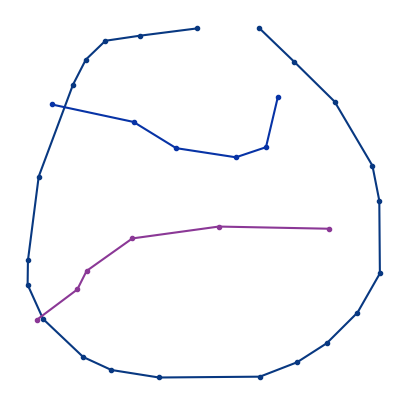

In [39]:
#change the index as per requirement CATEGORIES = ["apple", "car", "donut", "ladder", "tree", "door", "baseball", "pizza", "hexagon", "circle"]
class_index = 6

assert 0 <= class_index < NUM_CLASSES, f"Invalid class index: {class_index}"
class_name = CATEGORIES[class_index]
sketch = generate_sketch(encoder, decoder, class_index, train_loader)

#visualizing generated sketches
visualize_pointwise_colored_general(sketch, is_delta=True, fixed_scale=False)
filename = f"{class_name}_generated.png"
save_generated_sketch_as_image(sketch, filename)

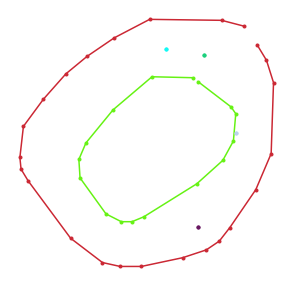

In [ ]:
drawing_index = 21040 #change it to visualize any drawing of the dataset loaded CATEGORIES = ["apple", "car", "donut", "ladder", "tree", "door", "baseball", "pizza", "hexagon", "circle"]
sample_drawing = drawings[drawing_index]
strokes_with_pen = convert_to_penstate(sample_drawing, y_max)
visualize_pointwise_colored_general(strokes_with_pen,
                                    delay=0.03,
                                    is_delta=False, fixed_scale=False)

In [ ]:
#Bonus question 2 to generate scene combining different sketches of different classes

In [ ]:
#user defined offset mapping
SCENE_TEMPLATE = {
    "apple":     {"x": -2.0, "y": 1.0},
    "car":       {"x": 0.0,  "y": -2.0},
    "donut":     {"x": 1.5,  "y": 1.0},
    "ladder":    {"x": -1.5, "y": 0.5},
    "tree":      {"x": -2.5, "y": 2.0},
    "door":      {"x": 0.5,  "y": 0.0},
    "baseball":  {"x": 2.5,  "y": -1.5},
    "pizza":     {"x": 1.0,  "y": -2.0},
    "hexagon":   {"x": -1.0, "y": -1.5},
    "circle":    {"x": 2.0,  "y": 1.5},
}

In [ ]:
def deltas_to_absolute(deltas, offset_x=0.0, offset_y=0.0):
    abs_strokes = []
    x, y = offset_x, offset_y
    for dx, dy, pen in deltas:
        x += dx
        y += dy
        abs_strokes.append((x, y, pen))
    return abs_strokes

#different generate function using the previous gnerate sketch function for generating scenes
def generate_scene(encoder, decoder, object_names, data_loader, template, max_seq_length=250, temperature=1.0):
    scene_strokes = []

    for i, obj_name in enumerate(object_names):
        class_idx = class_to_idx[obj_name]
        deltas = generate_sketch(encoder, decoder, class_idx, data_loader, max_seq_length, temperature)

        #to avoid break at pen state 2 of previous drawing
        deltas = [(dx, dy, pen) for dx, dy, pen in deltas if pen != 2]

        #to apply offset as per mapping
        offset_x = template.get(obj_name, {}).get("x", 0.0)
        offset_y = template.get(obj_name, {}).get("y", 0.0)
        abs_strokes = deltas_to_absolute(deltas, offset_x, offset_y)

        #add pen up between successive drawings of the scene
        if i > 0 and scene_strokes:
            last_x, last_y, _ = scene_strokes[-1]
            scene_strokes.append((last_x, last_y, 0))

        scene_strokes.extend(abs_strokes)

    return scene_strokes

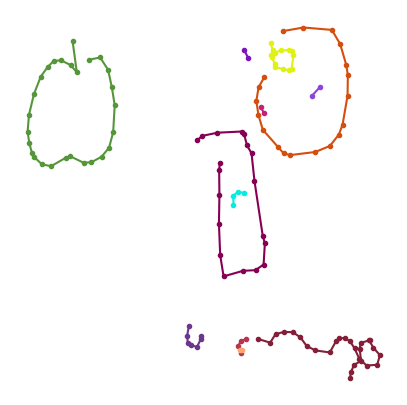

In [ ]:
#change the objects as per requirement CATEGORIES = ["apple", "car", "donut", "ladder", "tree", "door", "baseball", "pizza", "hexagon", "circle"]
objects = ["door", "donut", "car","apple"]
scene = generate_scene(encoder, decoder, objects, train_loader, SCENE_TEMPLATE)
#visualization of the scene
visualize_pointwise_colored_general(scene, is_delta=False, fixed_scale=False)
scene_name = "_".join(objects)
filename = f"{scene_name}_generated.png"
save_generated_sketch_as_image(scene, filename, is_delta=False)

In [ ]:
#bonus question 1 to take feedback from user to do ammendments in the generated drawing.
#the user ammends the generated sketch in paint or quickview and save it in directory

In [ ]:
import cv2
#function to convert ammended image to strokes and pen states
def image_to_strokes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

    contour_data = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contours = contour_data[0] if len(contour_data) == 2 else contour_data[1]

    strokes = []
    for contour in contours:
        for i, pt in enumerate(contour):
            x, y = pt[0]
            pen = 1 if i > 0 else 0
            strokes.append((float(x), float(y), pen))
        if strokes:
            x, y, _ = strokes[-1]
            strokes.append((x, y, 0))

    if strokes:
        x, y, _ = strokes[-1]
        strokes.append((x, y, 2))

    return strokes

import torch
#function to covert the strokes to tensors now
def strokes_to_tensor(strokes):
    tensor_data = []
    for dx, dy, pen in strokes:
        pen_one_hot = [0, 0, 0]
        pen_one_hot[int(pen)] = 1
        tensor_data.append([dx, dy] + pen_one_hot)

    return torch.tensor(tensor_data, dtype=torch.float32).unsqueeze(0).to(DEVICE)

#set path of the edited file
edited_abs = image_to_strokes("edited_apple.png")
edited_deltas = convert_to_deltas(edited_abs)
edited_tensor = strokes_to_tensor(edited_deltas)

In [ ]:
class_name = "apple"  #class being edited
class_index = class_to_idx[class_name]
assert 0 <= class_index < NUM_CLASSES

#retrieve the encoder input for this class
for batch_X, batch_Y, batch_class in train_loader:
    mask = (batch_class == class_index)
    if mask.any():
        idx = mask.nonzero(as_tuple=True)[0][0]
        input_seq = batch_X[idx:idx+1].to(DEVICE)
        break


In [ ]:
#function to fine tune the model as per edited drawing
def fine_tune_on_correction(encoder, decoder, input_seq, target_seq, class_label, num_steps=3, lr=1e-5):
    encoder.train()
    decoder.train()

    optimizer = torch.optim.AdamW(
        list(encoder.parameters()) + list(decoder.parameters()), lr=lr
    )

    mse_loss = nn.MSELoss()
    ce_loss = nn.CrossEntropyLoss()

    for _ in range(num_steps):
        optimizer.zero_grad()

        # Forward pass through encoder
        encoder_outputs, hidden, cell = encoder(input_seq, class_label)

        loss = 0
        input_step = input_seq[:, 0:1, :]  # start with first input

        for t in range(1, target_seq.shape[1]):
            output, hidden, cell, _ = decoder(input_step, hidden, cell, encoder_outputs, class_label)

            # MSE for dx/dy
            dxdy_loss = mse_loss(output[:, :2], target_seq[:, t, :2])

            # Cross-entropy for pen state (one-hot to class)
            pen_loss = ce_loss(output[:, 2:], target_seq[:, t, 2:].argmax(dim=1))

            loss += dxdy_loss + pen_loss

            # Teacher forcing
            input_step = target_seq[:, t:t+1, :]

        loss.backward()
        optimizer.step()


In [ ]:
fine_tune_on_correction(
    encoder, decoder,
    input_seq=input_seq,
    target_seq=edited_tensor,
    class_label=torch.tensor([class_index]).to(DEVICE),
    num_steps=5  #we can increase for better finetuning
)


In [ ]:
#generate new sketch after fine-tuning
regenerated_sketch = generate_sketch(encoder, decoder, class_index, train_loader)

#visualize
visualize_pointwise_colored_general(regenerated_sketch, is_delta=True, fixed_scale=False)

#save the updated sketch
filename = f"{CATEGORIES[class_index]}_after_finetune.png"
save_generated_sketch_as_image(regenerated_sketch, filename, is_delta=True)
print(f"Regenerated and saved to: {filename}")